# Классификация городских эпидемических волн по форме синтетических кривых


## 1. Идея

1. Для синтетических SEIR-траекторий берётся ранний участок эпидемии: небольшой фон до начала роста и сегмент до пика.
2. Из этого участка извлекаются признаки формы: время до пика, длительность, площадь под нормированной кривой, скорость роста и спада, ширина на половине максимума, асимметрия, ранний наклон и число локальных пиков.
3. Масштабные признаки исключаются из обучения, чтобы классификатор сравнивал форму, а не абсолютную высоту вспышки.
4. Модель обучается различать синтетические кривые `barabasi_albert_graph` и `watts_strogatz_graph`.
5. Для городских данных модель возвращает вероятности сходства с каждым синтетическим типом.


## 2. Импорты и параметры


In [9]:
from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


In [10]:
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
SPLITS_DIR = DATA_DIR / 'splits'

CITY_DATA_PATH_CANDIDATES = [
    Path(os.environ['CITY_DATA_PATH']) if os.environ.get('CITY_DATA_PATH') else None,
    DATA_DIR / 'indices_in_big_cities.csv',
    DATA_DIR / 'indices_in_big_cities.xlsx',
    ROOT / 'Data' / 'indices_in_big_cities.csv',
    ROOT / 'Data' / 'indices_in_big_cities.xlsx',
    ROOT / 'indices_in_big_cities.csv',
    ROOT / 'indices_in_big_cities.xlsx',
]
CITY_DATA_PATH_CANDIDATES = [path for path in CITY_DATA_PATH_CANDIDATES if path is not None]
CITY_DATA_PATH = next((path for path in CITY_DATA_PATH_CANDIDATES if path.exists()), CITY_DATA_PATH_CANDIDATES[0])
CITY_DATA_AVAILABLE = CITY_DATA_PATH.exists()


In [11]:
# Поддерживаем только два синтетических класса, для которых дальше строится сравнение городских волн.
GRAPH_LABELS = {
    'barabasi_albert_graph': 'barabasi_albert_graph',
    'watts_strogatz_graph': 'watts_strogatz_graph',
}

RANDOM_STATE = 42
MIN_SYNTHETIC_POINTS = 8
MIN_CITY_WAVE_POINTS = 6
CITY_START_YEAR = 2009

# Индекс split-ов хранит исходный путь в initial и переиндексированный файл в finite.
RESPLIT_SYNTHETIC_DATA = True
BALANCE_SYNTHETIC_STRATA = True
BALANCE_STRATIFY_COLUMNS = ['label', 'lam']
TRAIN_SIZE = 0.60
VAL_SIZE = 0.20
TEST_SIZE = 0.20
MIN_CLASS_RECALL_FOR_ACCEPTANCE = 1e-12

CITY_WAVE_OVERLAP_IOU_THRESHOLD = 0.60
CITY_PRE_EPIDEMIC_WEEKS = 2
CITY_COMPARISON_END = 'peak'
SYNTHETIC_PRE_EPIDEMIC_POINTS = 2
SYNTHETIC_COMPARISON_END = 'peak'

# Эти признаки отражают масштаб ряда, поэтому исключаем их из модели формы.
EXCLUDED_MODEL_FEATURES = ['n_points', 'raw_peak', 'peak_value']


## 3. Признаки формы эпидемической кривой


In [12]:
def _as_clean_float_array(y):
    """Преобразует ряд в неотрицательный числовой массив без NaN и бесконечностей."""
    arr = pd.to_numeric(pd.Series(y), errors='coerce').replace([np.inf, -np.inf], np.nan).to_numpy(dtype=float)
    arr = arr[~np.isnan(arr)]
    arr[arr < 0] = 0
    return arr


def normalize_curve(y):
    """Нормирует кривую на максимум"""
    arr = _as_clean_float_array(y)
    if arr.size == 0:
        return arr

    max_value = np.nanmax(arr)
    if not np.isfinite(max_value) or max_value <= 0:
        return np.zeros_like(arr, dtype=float)
    return arr / max_value


def curve_area(y):
    """Считает площадь под кривой"""
    if hasattr(np, 'trapezoid'):
        return np.trapezoid(y)
    return np.trapz(y)


def count_local_peaks(y, min_prominence=0.05):
    """Считает локальные пики нормированной кривой выше минимальной выраженности."""
    arr = np.asarray(y, dtype=float)
    if arr.size < 3:
        return 0

    peaks = 0
    for i in range(1, arr.size - 1):
        is_peak = arr[i] >= arr[i - 1] and arr[i] >= arr[i + 1]
        is_prominent = arr[i] - min(arr[i - 1], arr[i + 1]) >= min_prominence
        peaks += int(is_peak and is_prominent)
    return peaks


def extract_curve_features(y):
    """Извлекает признаки формы эпидемической кривой для обучения и сравнения волн."""
    raw = _as_clean_float_array(y)
    n = int(raw.size)
    empty_features = {
        'n_points': 0,
        'raw_peak': 0.0,
        'peak_value': 0.0,
        'time_to_peak': 0.0,
        'duration': 0.0,
        'auc': 0.0,
        'max_growth': 0.0,
        'max_decline': 0.0,
        'width_at_half_max': 0.0,
        'early_slope': 0.0,
        'num_peaks': 0,
        'mean_value': 0.0,
        'std_value': 0.0,
    }
    if n == 0:
        return empty_features

    arr = normalize_curve(raw)
    peak_idx = int(np.argmax(arr))
    denom = max(n - 1, 1)
    diff = np.diff(arr) if n > 1 else np.array([0.0])

    half_positions = np.where(arr >= 0.5)[0]
    width_at_half_max = 0.0
    if half_positions.size:
        width_at_half_max = float((half_positions[-1] - half_positions[0] + 1) / n)

    left_area = float(curve_area(arr[:peak_idx + 1])) if peak_idx > 0 else 0.0
    right_area = float(curve_area(arr[peak_idx:])) if peak_idx < n - 1 else 0.0

    early_window = max(3, min(n, int(np.ceil(n * 0.2))))
    early_y = arr[:early_window]
    early_slope = 0.0
    if early_window >= 2 and np.std(early_y) > 0:
        early_slope = float(np.polyfit(np.arange(early_window, dtype=float), early_y, 1)[0])

    return {
        'n_points': n,
        'raw_peak': float(np.max(raw)),
        'peak_value': float(np.max(arr)),
        'time_to_peak': float(peak_idx / denom),
        'duration': float(np.sum(arr > 0.05) / n),
        'auc': float(curve_area(arr) / denom) if n > 1 else float(arr[0]),
        'max_growth': float(np.max(diff)) if diff.size else 0.0,
        'max_decline': float(abs(np.min(diff))) if diff.size else 0.0,
        'width_at_half_max': width_at_half_max,
        'early_slope': early_slope,
        'num_peaks': int(count_local_peaks(arr)),
        'mean_value': float(np.mean(arr)),
        'std_value': float(np.std(arr)),
    }


FEATURE_COLUMNS = list(extract_curve_features([0, 1, 2, 1]).keys())
MODEL_FEATURE_COLUMNS = [column for column in FEATURE_COLUMNS if column not in EXCLUDED_MODEL_FEATURES]
display(pd.Series(MODEL_FEATURE_COLUMNS, name='model_feature'))


0         time_to_peak
1             duration
2                  auc
3           max_growth
4          max_decline
5    width_at_half_max
6          early_slope
7            num_peaks
8           mean_value
9            std_value
Name: model_feature, dtype: object

## 4. Загрузка синтетических данных


In [13]:
def extract_graph_kind(relative_path):
    """Достаёт тип графа из пути к исходной синтетической симуляции."""
    match = re.search(r'simulations[\\/]+([^\\/]+)[\\/]+', str(relative_path))
    return match.group(1) if match else None


def extract_lam(relative_path):
    """Достаёт значение lambda из пути к исходной синтетической симуляции."""
    match = re.search(r'lam=([^\\/]+)', str(relative_path))
    if not match:
        return np.nan
    return pd.to_numeric(match.group(1), errors='coerce')


def finite_curve_path(split_dir, row):
    """Возвращает путь к переиндексированному CSV-файлу кривой внутри split-а."""
    if not hasattr(row, 'finite') or pd.isna(getattr(row, 'finite')):
        raise ValueError('Индекс split-а должен содержать непустую колонку finite.')
    return split_dir / f'seir_seed_{int(getattr(row, "finite"))}.csv'


def extract_synthetic_comparison_curve(curve):
    """Берёт из синтетической кривой ранний участок: фон перед ростом и сегмент до пика."""
    arr = _as_clean_float_array(curve)
    if arr.size == 0 or np.max(arr) <= 0:
        return arr, 0, max(0, arr.size - 1)

    normalized = normalize_curve(arr)
    peak_idx = int(np.argmax(normalized))
    growth_candidates = np.where(normalized[:peak_idx + 1] > 0.05)[0]
    start_idx = int(growth_candidates[0]) if growth_candidates.size else 0
    comparison_start_idx = max(0, start_idx - SYNTHETIC_PRE_EPIDEMIC_POINTS)
    comparison_end_idx = peak_idx if SYNTHETIC_COMPARISON_END == 'peak' else arr.size - 1
    comparison_end_idx = max(comparison_end_idx, comparison_start_idx)
    return arr[comparison_start_idx:comparison_end_idx + 1], comparison_start_idx, comparison_end_idx


def load_synthetic_split(split_name):
    """Загружает один split синтетических кривых и возвращает таблицы признаков и пропусков."""
    split_dir = SPLITS_DIR / split_name
    index_path = split_dir / f'{split_name}_index.csv'
    if not index_path.exists():
        raise FileNotFoundError(index_path)

    index_df = pd.read_csv(index_path)
    missing_columns = {'initial', 'finite'}.difference(index_df.columns)
    if missing_columns:
        raise ValueError(f'{index_path} не содержит обязательные колонки: {sorted(missing_columns)}')

    records = []
    skipped = []
    for row in index_df.itertuples(index=False):
        relative_path = getattr(row, 'initial')
        graph_kind = extract_graph_kind(relative_path)
        lam = extract_lam(relative_path)
        curve_path = finite_curve_path(split_dir, row)

        if graph_kind not in GRAPH_LABELS:
            skipped.append({'path': relative_path, 'reason': f'неподдерживаемый graph_kind={graph_kind}'})
            continue
        if not curve_path.exists():
            skipped.append({'path': relative_path, 'finite_file': str(curve_path), 'reason': 'нет finite-файла'})
            continue

        curve_df = pd.read_csv(curve_path)
        if 'I' not in curve_df.columns:
            skipped.append({'path': relative_path, 'finite_file': str(curve_path), 'reason': 'нет колонки I'})
            continue

        curve = _as_clean_float_array(curve_df['I'])
        comparison_curve, start_idx, end_idx = extract_synthetic_comparison_curve(curve)
        if comparison_curve.size < MIN_SYNTHETIC_POINTS or np.max(comparison_curve) <= 0:
            skipped.append({'path': relative_path, 'finite_file': str(curve_path), 'reason': 'ранний участок слишком короткий или плоский'})
            continue

        features = extract_curve_features(comparison_curve)
        features.update({
            'full_n_points': int(curve.size),
            'comparison_start_idx': int(start_idx),
            'comparison_end_idx': int(end_idx),
            'source_split': split_name,
            'split': split_name,
            'label': GRAPH_LABELS[graph_kind],
            'graph_kind': graph_kind,
            'lam': lam,
            'curve_path': str(curve_path),
            'finite_file': curve_path.name,
            'finite_id': int(getattr(row, 'finite')),
            'source_relative_path': relative_path,
        })
        records.append(features)

    features_df = pd.DataFrame(records)
    skipped_df = pd.DataFrame(skipped)
    if len(features_df) + len(skipped_df) != len(index_df):
        raise AssertionError(f'{split_name}: число загруженных и пропущенных строк не совпадает с индексом.')
    if not skipped_df.empty:
        raise ValueError(f'{split_name}: пропущено строк: {len(skipped_df)}. Сначала проверьте synthetic_skipped.')
    return features_df, skipped_df


def load_all_synthetic_splits(split_names=('train', 'val', 'test')):
    """Загружает все синтетические split-ы и объединяет их в общие таблицы."""
    feature_parts = []
    skipped_parts = []
    for split_name in split_names:
        split_features, split_skipped = load_synthetic_split(split_name)
        feature_parts.append(split_features)
        skipped_parts.append(split_skipped.assign(split=split_name))
    return pd.concat(feature_parts, ignore_index=True), pd.concat(skipped_parts, ignore_index=True)


In [14]:
synthetic_features, synthetic_skipped = load_all_synthetic_splits()
if synthetic_features.empty:
    raise ValueError('Не удалось загрузить ни одной пригодной синтетической траектории.')

feature_matrix = synthetic_features[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
nan_counts = feature_matrix.isna().sum().sort_values(ascending=False)

print('Синтетические строки по исходному split-у и классу:')
display(synthetic_features.groupby(['source_split', 'label']).size().unstack(fill_value=0))
print('Синтетические строки по классу и lambda:')
display(synthetic_features.groupby(['label', 'lam']).size().rename('n').reset_index())
print(f'Пропущенные строки: {len(synthetic_skipped)}')
display(synthetic_skipped.head())
print('NaN в матрице признаков модели:')
display(nan_counts[nan_counts > 0])
print('Первые соответствия исходных и finite-файлов:')
display(synthetic_features[['source_split', 'source_relative_path', 'finite_file', 'curve_path', 'label', 'lam']].head(10))


Синтетические строки по исходному split-у и классу:


label,barabasi_albert_graph,watts_strogatz_graph
source_split,,
test,10,2
train,32,6
val,8,2


Синтетические строки по классу и lambda:


,label,lam,n
0,barabasi_albert_graph,4,50
1,watts_strogatz_graph,16,10


Пропущенные строки: 0


,split


NaN в матрице признаков модели:


Series([], dtype: int64)

Первые соответствия исходных и finite-файлов:


,source_split,source_relative_path,finite_file,curve_path,label,lam
0,train,simulations/watts_strogatz_graph/lam=16/seir_s...,seir_seed_0.csv,c:\Users\user\Desktop\projects\topology_influe...,watts_strogatz_graph,16
1,train,simulations/barabasi_albert_graph/lam=4/seir_s...,seir_seed_1.csv,c:\Users\user\Desktop\projects\topology_influe...,barabasi_albert_graph,4
2,train,simulations/watts_strogatz_graph/lam=16/seir_s...,seir_seed_2.csv,c:\Users\user\Desktop\projects\topology_influe...,watts_strogatz_graph,16
3,train,simulations/barabasi_albert_graph/lam=4/seir_s...,seir_seed_3.csv,c:\Users\user\Desktop\projects\topology_influe...,barabasi_albert_graph,4
4,train,simulations/barabasi_albert_graph/lam=4/seir_s...,seir_seed_4.csv,c:\Users\user\Desktop\projects\topology_influe...,barabasi_albert_graph,4
5,train,simulations/barabasi_albert_graph/lam=4/seir_s...,seir_seed_5.csv,c:\Users\user\Desktop\projects\topology_influe...,barabasi_albert_graph,4
6,train,simulations/barabasi_albert_graph/lam=4/seir_s...,seir_seed_6.csv,c:\Users\user\Desktop\projects\topology_influe...,barabasi_albert_graph,4
7,train,simulations/barabasi_albert_graph/lam=4/seir_s...,seir_seed_7.csv,c:\Users\user\Desktop\projects\topology_influe...,barabasi_albert_graph,4
8,train,simulations/watts_strogatz_graph/lam=16/seir_s...,seir_seed_8.csv,c:\Users\user\Desktop\projects\topology_influe...,watts_strogatz_graph,16
9,train,simulations/watts_strogatz_graph/lam=16/seir_s...,seir_seed_9.csv,c:\Users\user\Desktop\projects\topology_influe...,watts_strogatz_graph,16


## 5. Обучение и проверка классификатора


In [63]:
def make_stratify_key(df, columns):
    """Создаёт ключ стратификации из нескольких колонок."""
    return df[columns].astype(str).agg('|'.join, axis=1)


def build_balanced_synthetic_dataset(df):
    """Балансирует синтетические данные по классу и lambda перед повторным разбиением."""
    work = df.copy()
    work['stratify_key'] = make_stratify_key(work, BALANCE_STRATIFY_COLUMNS)
    strata_counts = work['stratify_key'].value_counts().sort_index()
    if len(strata_counts) < 2:
        raise ValueError('Для обучения нужно минимум две синтетические страты.')

    if not BALANCE_SYNTHETIC_STRATA:
        return work, strata_counts

    min_count = int(strata_counts.min())
    if min_count < 5:
        raise ValueError(f'Недостаточно строк в минимальной страте для балансировки: min_count={min_count}')

    work = pd.concat(
        [group.sample(n=min_count, random_state=RANDOM_STATE) for _, group in work.groupby('stratify_key')],
        ignore_index=True,
    )
    work['stratify_key'] = make_stratify_key(work, BALANCE_STRATIFY_COLUMNS)
    return work, work['stratify_key'].value_counts().sort_index()


def split_synthetic_data(df):
    """Готовит train/val/test: либо повторно стратифицирует данные, либо использует готовые split-ы."""
    if not RESPLIT_SYNTHETIC_DATA:
        return (
            df[df['split'] == 'train'].copy(),
            df[df['split'] == 'val'].copy(),
            df[df['split'] == 'test'].copy(),
            None,
        )

    split_source, strata_counts = build_balanced_synthetic_dataset(df)
    train_df, holdout_df = train_test_split(
        split_source,
        train_size=TRAIN_SIZE,
        random_state=RANDOM_STATE,
        stratify=split_source['stratify_key'],
    )
    relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
    val_df, test_df = train_test_split(
        holdout_df,
        test_size=relative_test_size,
        random_state=RANDOM_STATE,
        stratify=holdout_df['stratify_key'],
    )
    return (
        train_df.assign(split='train').copy(),
        val_df.assign(split='val').copy(),
        test_df.assign(split='test').copy(),
        strata_counts,
    )


def validate_model_splits(splits):
    """Проверяет, что каждый split непустой и содержит оба синтетических класса."""
    for name, df in splits.items():
        if df.empty:
            raise ValueError(f'{name} split пустой после подготовки.')
        if df['label'].nunique() < 2:
            raise ValueError(f'{name} split содержит меньше двух классов.')


def make_models():
    """Создаёт сравниваемые модели классификации формы кривых."""
    return {
        'logistic_regression': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
        ]),
        'random_forest': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                class_weight='balanced',
                random_state=RANDOM_STATE,
            )),
        ]),
    }


def score_models(models, X_train, y_train, X_val, y_val):
    """Обучает модели и считает validation-метрики для выбора лучшей модели."""
    scores = []
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        per_class_recall = recall_score(y_val, val_pred, labels=model.classes_, average=None, zero_division=0)
        scores.append({
            'model': model_name,
            'val_accuracy': accuracy_score(y_val, val_pred),
            'val_balanced_accuracy': balanced_accuracy_score(y_val, val_pred),
            'val_f1_macro': f1_score(y_val, val_pred, average='macro'),
            'val_min_class_recall': float(np.min(per_class_recall)),
        })
    return pd.DataFrame(scores).sort_values(
        ['val_min_class_recall', 'val_f1_macro', 'val_balanced_accuracy', 'val_accuracy'],
        ascending=False,
    )


def train_and_select_model(train_df, val_df):
    """Обучает кандидатов и выбирает модель, которая не теряет ни один класс на validation."""
    models = make_models()
    model_scores = score_models(
        models,
        train_df[MODEL_FEATURE_COLUMNS],
        train_df['label'],
        val_df[MODEL_FEATURE_COLUMNS],
        val_df['label'],
    )
    acceptable_scores = model_scores[model_scores['val_min_class_recall'] > MIN_CLASS_RECALL_FOR_ACCEPTANCE]
    if acceptable_scores.empty:
        raise ValueError('Ни одна модель не прошла validation: у одного из классов recall равен нулю.')

    best_model_name = acceptable_scores.iloc[0]['model']
    return best_model_name, models[best_model_name], model_scores


def evaluate_model(model, model_name, test_df):
    """Проверяет выбранную модель на held-out test и строит матрицу ошибок."""
    X_test = test_df[MODEL_FEATURE_COLUMNS]
    y_test = test_df['label']
    test_pred = model.predict(X_test)
    labels = list(model.classes_)
    per_class_recall = recall_score(y_test, test_pred, labels=labels, average=None, zero_division=0)
    metrics = {
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, test_pred),
        'test_macro_f1': f1_score(y_test, test_pred, average='macro'),
        'test_min_class_recall': float(np.min(per_class_recall)),
    }

    print('Test-метрики:')
    display(pd.DataFrame([metrics]))
    print('\nClassification report:')
    print(classification_report(y_test, test_pred, labels=labels, zero_division=0))

    if metrics['test_min_class_recall'] <= MIN_CLASS_RECALL_FOR_ACCEPTANCE:
        raise ValueError('Выбранная модель не прошла test: у одного из классов recall равен нулю.')

    cm = confusion_matrix(y_test, test_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Матрица ошибок на test: {model_name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.tight_layout()
    plt.show()
    return metrics


Сбалансированные страты для повторного train/val/test разбиения:


,stratify_key,n
0,barabasi_albert_graph|4,10
1,watts_strogatz_graph|16,10


Признаки, используемые моделью:


0          time_to_peak
1              duration
2                   auc
3            max_growth
4           max_decline
5     width_at_half_max
6             asymmetry
7           early_slope
8             num_peaks
9            mean_value
10            std_value
Name: feature, dtype: object

Финальное распределение split-ов по классам:


...

,split,label,lam,n
0,test,barabasi_albert_graph,4,2
1,test,watts_strogatz_graph,16,2
2,train,barabasi_albert_graph,4,6
3,train,watts_strogatz_graph,16,6
4,val,barabasi_albert_graph,4,2
5,val,watts_strogatz_graph,16,2


,model,val_accuracy,val_balanced_accuracy,val_f1_macro,val_min_class_recall
0,logistic_regression,1.0,1.0,1.0,1.0
1,random_forest,1.0,1.0,1.0,1.0


Лучшая принятая модель: logistic_regression
Test-метрики:


,test_accuracy,test_balanced_accuracy,test_macro_f1,test_min_class_recall
0,1.0,1.0,1.0,1.0



Classification report:
                       precision    recall  f1-score   support

barabasi_albert_graph       1.00      1.00      1.00         2
 watts_strogatz_graph       1.00      1.00      1.00         2

             accuracy                           1.00         4
            macro avg       1.00      1.00      1.00         4
         weighted avg       1.00      1.00      1.00         4



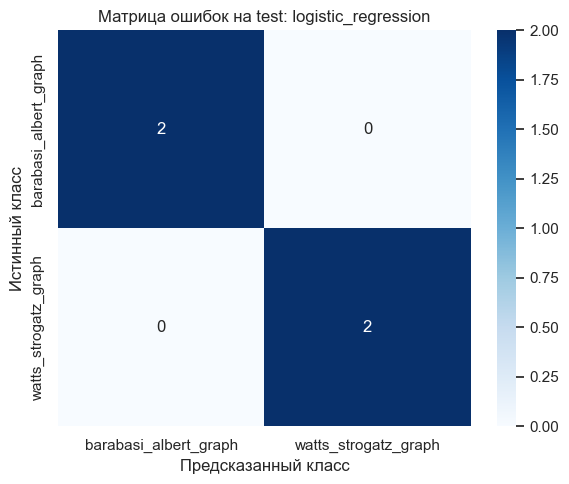

In [64]:
train_df, val_df, test_df, balanced_strata_counts = split_synthetic_data(synthetic_features)
validate_model_splits({'train': train_df, 'val': val_df, 'test': test_df})

if balanced_strata_counts is not None:
    print('Сбалансированные страты для повторного train/val/test разбиения:')
    display(balanced_strata_counts.rename('n').reset_index())

final_splits = pd.concat([train_df, val_df, test_df], ignore_index=True)
print('Признаки, используемые моделью:')
display(pd.Series(MODEL_FEATURE_COLUMNS, name='feature'))
print('Финальное распределение split-ов по классам:')
display(final_splits.groupby(['split', 'label']).size().unstack(fill_value=0))
print('Финальное распределение split-ов по классам и lambda:')
display(final_splits.groupby(['split', 'label', 'lam']).size().rename('n').reset_index())

best_model_name, best_model, model_scores = train_and_select_model(train_df, val_df)
display(model_scores)
print(f'Лучшая принятая модель: {best_model_name}')

test_metrics = evaluate_model(best_model, best_model_name, test_df)


## 6. Загрузка городских данных


In [65]:
def read_city_dataframe(path):
    """Читает городской файл CSV или Excel в DataFrame."""
    suffix = path.suffix.lower()
    if suffix in {'.xlsx', '.xls'}:
        return pd.read_excel(path, sheet_name=0)
    if suffix == '.csv':
        return pd.read_csv(path, delimiter=';')
    raise ValueError(f'Неподдерживаемый формат городских данных: {path}')


def load_city_dataframe():
    """Загружает, проверяет и подготавливает городские недельные ряды."""
    if not CITY_DATA_AVAILABLE:
        print(
            'Файл городских данных не найден, городской анализ будет пропущен. '
            f'Проверенные пути: {[str(path) for path in CITY_DATA_PATH_CANDIDATES]}. '
            'Поместите indices_in_big_cities.csv/xlsx в data/ или задайте CITY_DATA_PATH.'
        )
        return pd.DataFrame()

    city_df = read_city_dataframe(CITY_DATA_PATH)
    required_columns = {'town_name', 'cld_year', 'week_number', 'wd_total', 'qty_total'}
    missing_columns = required_columns.difference(city_df.columns)
    if missing_columns:
        raise ValueError(f'В городских данных нет обязательных колонок: {sorted(missing_columns)}')

    numeric_columns = ['cld_year', 'week_number', 'wd_total', 'qty_total']
    city_df[numeric_columns] = city_df[numeric_columns].apply(pd.to_numeric, errors='coerce')
    city_df = city_df[city_df['cld_year'] >= CITY_START_YEAR].copy()
    return city_df.sort_values(['town_name', 'cld_year', 'week_number']).reset_index(drop=True)


def show_city_data_summary(city_df):
    """Показывает краткую сводку по загруженным городским данным."""
    if city_df.empty:
        return

    print(f'Путь к городским данным: {CITY_DATA_PATH}')
    print(f'Начальный год: {CITY_START_YEAR}')
    print(f'Строк: {len(city_df):,}')
    print(f'Городов: {city_df["town_name"].nunique()}')
    display(city_df.groupby('town_name').agg(
        rows=('wd_total', 'size'),
        non_missing_wd_total=('wd_total', lambda x: x.notna().sum()),
        first_year=('cld_year', 'min'),
        last_year=('cld_year', 'max'),
    ).reset_index())


In [66]:
city_df = load_city_dataframe()
show_city_data_summary(city_df)


Путь к городским данным: c:\Users\user\Desktop\projects\topology_influences_on_disease_spread\data\indices_in_big_cities.csv
Начальный год: 2009
Строк: 5,004
Городов: 12


,town_name,rows,non_missing_wd_total,first_year,last_year
0,Екатеринбург,417,365,2009,2016
1,Казань,417,365,2009,2016
2,Москва,417,365,2009,2016
3,Нижний_Новгород,417,365,2009,2016
4,Новосибирск,417,365,2009,2016
5,Омск,417,365,2009,2016
6,Пермь,417,365,2009,2016
7,Ростов-на-Дону,417,365,2009,2016
8,Самара,417,365,2009,2016
9,Санкт-Петербург,417,365,2009,2016


## 7. Поиск городских волн


In [67]:
def prepare_city_series(group):
    """Готовит сглаженный недельный ряд заболеваемости для одного города."""
    group = group.sort_values(['cld_year', 'week_number']).copy()
    y = group['wd_total'].astype(float)
    population = group['qty_total'].replace(0, np.nan).astype(float)
    if population.notna().sum() > 0:
        y = y / population

    y = y.interpolate(limit_direction='both')
    smooth = y.rolling(window=5, center=True, min_periods=1).median()
    smooth = smooth.rolling(window=3, center=True, min_periods=1).mean()
    return smooth.to_numpy(dtype=float)


def interval_iou(a_start, a_end, b_start, b_end):
    """Считает долю пересечения двух недельных интервалов относительно их объединения."""
    overlap = max(0, min(a_end, b_end) - max(a_start, b_start) + 1)
    if overlap == 0:
        return 0.0
    union = max(a_end, b_end) - min(a_start, b_start) + 1
    return overlap / union


def deduplicate_city_waves(waves, overlap_threshold=CITY_WAVE_OVERLAP_IOU_THRESHOLD):
    """Удаляет сильно пересекающиеся городские волны, оставляя более выраженный пик."""
    kept = []
    dropped = []
    ranked = sorted(waves, key=lambda w: (w['peak_value'], len(w['curve'])), reverse=True)

    for wave in ranked:
        duplicate_of = None
        duplicate_iou = 0.0
        for kept_wave in kept:
            iou = interval_iou(wave['start_idx'], wave['end_idx'], kept_wave['start_idx'], kept_wave['end_idx'])
            if iou >= overlap_threshold:
                duplicate_of = kept_wave
                duplicate_iou = iou
                break

        if duplicate_of is None:
            kept.append(wave)
            continue

        dropped.append({
            'dropped_peak_year': wave['peak_year'],
            'dropped_peak_week': wave['peak_week'],
            'dropped_start_year': wave['start_year'],
            'dropped_start_week': wave['start_week'],
            'dropped_end_year': wave['end_year'],
            'dropped_end_week': wave['end_week'],
            'kept_peak_year': duplicate_of['peak_year'],
            'kept_peak_week': duplicate_of['peak_week'],
            'kept_start_year': duplicate_of['start_year'],
            'kept_start_week': duplicate_of['start_week'],
            'kept_end_year': duplicate_of['end_year'],
            'kept_end_week': duplicate_of['end_week'],
            'overlap_iou': duplicate_iou,
            'dropped_peak_value': wave['peak_value'],
            'kept_peak_value': duplicate_of['peak_value'],
        })

    return sorted(kept, key=lambda w: (w['start_idx'], w['peak_idx'], w['end_idx'])), dropped


def find_candidate_peaks(series):
    """Находит кандидаты в пики городского ряда выше адаптивного порога."""
    threshold = max(np.nanquantile(series, 0.75), np.nanmean(series) + 0.5 * np.nanstd(series))
    min_distance = 10
    peaks = []
    for i in range(1, len(series) - 1):
        is_peak = series[i] >= threshold and series[i] >= series[i - 1] and series[i] >= series[i + 1]
        if not is_peak:
            continue
        if not peaks or i - peaks[-1] >= min_distance:
            peaks.append(i)
        elif series[i] > series[peaks[-1]]:
            peaks[-1] = i
    return peaks or [int(np.nanargmax(series))]


def make_city_wave_record(group, series, start, peak_idx, end):
    """Формирует описание городской волны и участка для сравнения с синтетикой."""
    comparison_start = max(0, start - CITY_PRE_EPIDEMIC_WEEKS)
    comparison_end = peak_idx if CITY_COMPARISON_END == 'peak' else end
    if comparison_end - comparison_start + 1 < MIN_CITY_WAVE_POINTS:
        comparison_end = min(end, comparison_start + MIN_CITY_WAVE_POINTS - 1)

    wave = series[start:end + 1]
    comparison_curve = series[comparison_start:comparison_end + 1]
    if len(wave) < MIN_CITY_WAVE_POINTS or len(comparison_curve) < MIN_CITY_WAVE_POINTS or np.nanmax(comparison_curve) <= 0:
        return None

    return {
        'start_idx': int(start),
        'end_idx': int(end),
        'peak_idx': int(peak_idx),
        'comparison_start_idx': int(comparison_start),
        'comparison_end_idx': int(comparison_end),
        'peak_value': float(series[peak_idx]),
        'curve': wave,
        'comparison_curve': comparison_curve,
        'start_year': int(group.loc[start, 'cld_year']),
        'start_week': int(group.loc[start, 'week_number']),
        'end_year': int(group.loc[end, 'cld_year']),
        'end_week': int(group.loc[end, 'week_number']),
        'comparison_start_year': int(group.loc[comparison_start, 'cld_year']),
        'comparison_start_week': int(group.loc[comparison_start, 'week_number']),
        'comparison_end_year': int(group.loc[comparison_end, 'cld_year']),
        'comparison_end_week': int(group.loc[comparison_end, 'week_number']),
        'peak_year': int(group.loc[peak_idx, 'cld_year']),
        'peak_week': int(group.loc[peak_idx, 'week_number']),
    }


def find_city_waves(group, min_points=MIN_CITY_WAVE_POINTS):
    """Находит непересекающиеся эпидемические волны для одного города."""
    group = group.sort_values(['cld_year', 'week_number']).reset_index(drop=True).copy()
    y = prepare_city_series(group)
    valid = np.isfinite(y) & (y >= 0)
    if valid.sum() < min_points or np.nanmax(y[valid]) <= 0:
        return [], 'недостаточно непустых наблюдений', []

    series = pd.Series(np.where(valid, y, np.nan)).interpolate(limit_direction='both').to_numpy(dtype=float)
    waves = []
    for peak_idx in find_candidate_peaks(series):
        peak_value = series[peak_idx]
        if peak_value <= 0:
            continue

        boundary_level = max(0.15 * peak_value, np.nanquantile(series, 0.35))
        start = peak_idx
        while start > 0 and series[start] > boundary_level:
            start -= 1
        end = peak_idx
        while end < len(series) - 1 and series[end] > boundary_level:
            end += 1

        if end - start + 1 < min_points:
            pad = max(0, (min_points - (end - start + 1)) // 2 + 1)
            start = max(0, start - pad)
            end = min(len(series) - 1, end + pad)

        wave = make_city_wave_record(group, series, start, peak_idx, end)
        if wave is not None:
            waves.append(wave)

    deduped_waves, overlap_drops = deduplicate_city_waves(waves)
    return deduped_waves, None, overlap_drops


def detect_city_waves(city_df):
    """Ищет волны во всех городах и возвращает признаки, кривые, проблемы и удалённые дубли."""
    if city_df.empty:
        return (
            pd.DataFrame(),
            [],
            pd.DataFrame([{'city': None, 'issue': 'городские данные недоступны; поиск волн пропущен'}]),
            pd.DataFrame(),
        )

    records = []
    curves = []
    issues = []
    overlap_records = []

    for city, group in city_df.groupby('town_name'):
        waves, issue, overlap_drops = find_city_waves(group)
        overlap_records.extend(dict(drop, city=city) for drop in overlap_drops)
        if issue:
            issues.append({'city': city, 'issue': issue})
            continue

        for wave_id, wave in enumerate(waves, start=1):
            features = extract_curve_features(wave['comparison_curve'])
            features.update({
                'city': city,
                'wave_id': wave_id,
                'start_year': wave['start_year'],
                'start_week': wave['start_week'],
                'end_year': wave['end_year'],
                'end_week': wave['end_week'],
                'peak_year': wave['peak_year'],
                'peak_week': wave['peak_week'],
                'comparison_start_year': wave['comparison_start_year'],
                'comparison_start_week': wave['comparison_start_week'],
                'comparison_end_year': wave['comparison_end_year'],
                'comparison_end_week': wave['comparison_end_week'],
                'full_wave_n_points': len(wave['curve']),
                'peak_value_city_series': wave['peak_value'],
            })
            records.append(features)
            curves.append({'city': city, 'wave_id': wave_id, 'curve': wave['comparison_curve']})

    return pd.DataFrame(records), curves, pd.DataFrame(issues), pd.DataFrame(overlap_records)


- Самара
- Санкт-Петербург

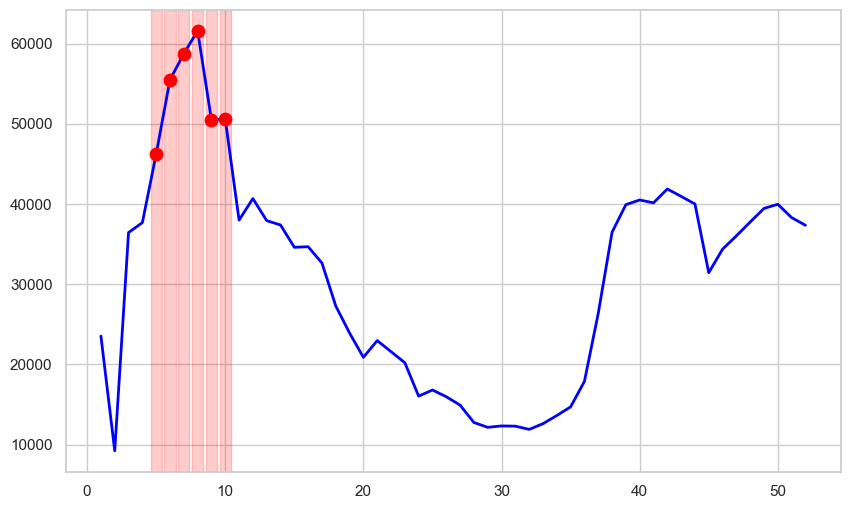

In [75]:
df_year_SPb = city_df[(city_df['town_name']=='Санкт-Петербург') & (city_df['cld_year'] == 2009)]
df_year_Sam = city_df[(city_df['town_name']=='Самара') & (city_df['cld_year'] == 2009)]

highlight_SPb = df_year_SPb[df_year_SPb['wda_total'] == 'Э']
highlight_Sam = df_year_Sam[df_year_Sam['wda_total'] == 'Э']

plt.figure(figsize=(10, 6))
plt.plot(df_year['week_number'], df_year['wd_total'], color='blue', linewidth=2)

for week in highlight['week_number']:
    plt.axvspan(week-0.4, week+0.4, alpha=0.2, color='red')

plt.scatter(highlight['week_number'], highlight['wd_total'],
            color='red', s=80, zorder=5)

plt.show()

In [76]:
highlight_SPb

,town_name,cld_year,week_number,wd_total,wda_total,qty_total
3761,Санкт-Петербург,2009,9,43622.0,Э,4568047.0
3762,Санкт-Петербург,2009,10,47759.0,Э,4568047.0
3763,Санкт-Петербург,2009,11,44916.0,Э,4568047.0
3764,Санкт-Петербург,2009,12,47161.0,Э,4568047.0
3765,Санкт-Петербург,2009,13,39269.0,Э,4568047.0
3766,Санкт-Петербург,2009,14,36169.0,Э,4568047.0
3796,Санкт-Петербург,2009,44,38650.0,Э,4568047.0
3797,Санкт-Петербург,2009,45,39594.0,Э,4568047.0
3798,Санкт-Петербург,2009,46,52948.0,Э,4568047.0
3799,Санкт-Петербург,2009,47,70272.0,Э,4568047.0


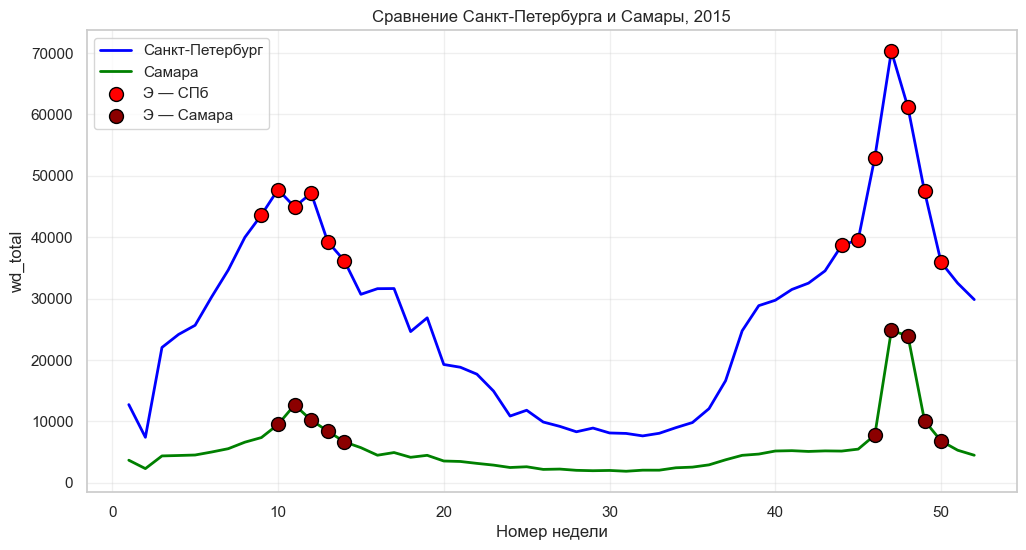

In [77]:
df_year_SPb = city_df[(city_df['town_name']=='Санкт-Петербург') & (city_df['cld_year'] == 2009)]
df_year_Sam = city_df[(city_df['town_name']=='Самара') & (city_df['cld_year'] == 2009)]

highlight_SPb = df_year_SPb[df_year_SPb['wda_total'] == 'Э']
highlight_Sam = df_year_Sam[df_year_Sam['wda_total'] == 'Э']

plt.figure(figsize=(12, 6))

plt.plot(df_year_SPb['week_number'], df_year_SPb['wd_total'], 
         color='blue', linewidth=2, label='Санкт-Петербург')

plt.plot(df_year_Sam['week_number'], df_year_Sam['wd_total'], 
         color='green', linewidth=2, label='Самара')

# Подсветка для СПб
plt.scatter(highlight_SPb['week_number'], highlight_SPb['wd_total'],
            color='red', s=100, zorder=5, edgecolors='black', label='Э — СПб')

# Подсветка для Самары
plt.scatter(highlight_Sam['week_number'], highlight_Sam['wd_total'],
            color='darkred', s=100, zorder=5, edgecolors='black', label='Э — Самара')

plt.title('Сравнение Санкт-Петербурга и Самары, 2015')
plt.xlabel('Номер недели')
plt.ylabel('wd_total')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
city_waves, city_wave_curves, city_wave_issues, city_wave_overlaps = detect_city_waves(city_df)

if city_df.empty:
    print('Поиск городских волн пропущен: city_df пустой.')
else:
    print(f'Найдено городских волн после удаления пересечений: {len(city_waves)}')
    print(f'Участок сравнения: {CITY_PRE_EPIDEMIC_WEEKS} недели до начала волны и до {CITY_COMPARISON_END}')
    print(f'Удалено пересекающихся кандидатов: {len(city_wave_overlaps)}')
    if not city_waves.empty:
        display(city_waves.groupby('city').size().rename('n_waves').reset_index())
    if not city_wave_overlaps.empty:
        display(city_wave_overlaps.sort_values(['city', 'overlap_iou'], ascending=[True, False]).head(30))
    if not city_wave_issues.empty:
        display(city_wave_issues)


Найдено городских волн после удаления пересечений: 94
Участок сравнения: 2 недели до начала волны и до peak
Удалено пересекающихся кандидатов: 43


,city,n_waves
0,Екатеринбург,8
1,Казань,7
2,Москва,8
3,Нижний_Новгород,8
4,Новосибирск,7
5,Омск,8
6,Пермь,8
7,Ростов-на-Дону,7
8,Самара,8
9,Санкт-Петербург,10


,dropped_peak_year,dropped_peak_week,dropped_start_year,dropped_start_week,dropped_end_year,dropped_end_week,kept_peak_year,kept_peak_week,kept_start_year,kept_start_week,kept_end_year,kept_end_week,overlap_iou,dropped_peak_value,kept_peak_value,city
0,2014,39,2014,35,2015,19,2015,7,2014,35,2015,19,1.0,0.007034,0.012068,Екатеринбург
1,2010,7,2009,42,2010,19,2009,46,2009,42,2010,19,1.0,0.006889,0.012388,Екатеринбург
2,2011,51,2011,37,2012,19,2012,11,2011,37,2012,19,1.0,0.006479,0.006970,Екатеринбург
3,2016,9,2015,35,2016,52,2015,51,2015,35,2016,52,1.0,0.006438,0.006438,Екатеринбург
4,2016,19,2015,35,2016,52,2015,51,2015,35,2016,52,1.0,0.006438,0.006438,Екатеринбург
5,2016,29,2015,35,2016,52,2015,51,2015,35,2016,52,1.0,0.006438,0.006438,Екатеринбург
6,2016,39,2015,35,2016,52,2015,51,2015,35,2016,52,1.0,0.006438,0.006438,Екатеринбург
7,2016,49,2015,35,2016,52,2015,51,2015,35,2016,52,1.0,0.006438,0.006438,Екатеринбург
8,2010,7,2009,39,2010,19,2009,47,2009,39,2010,19,1.0,0.006178,0.012337,Казань
9,2014,50,2014,37,2015,19,2015,10,2014,37,2015,19,1.0,0.005728,0.007732,Казань


## 8. Сравнение городских волн с синтетическими классами


In [13]:
def classify_city_waves(city_waves, model):
    """Считает вероятности сходства городских волн с синтетическими классами."""
    if city_waves.empty:
        print('Сравнение городских волн с синтетикой пропущено: волн нет или городские данные недоступны.')
        return pd.DataFrame(), pd.DataFrame()

    print(
        'Предупреждение об интерпретации: это вероятности сходства формы с синтетическими кривыми, '
        'а не подтверждённые метки реальной городской топологии.'
    )

    city_X = city_waves[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
    similarity_class = model.predict(city_X)
    similarity_proba = model.predict_proba(city_X)
    class_to_index = {label: idx for idx, label in enumerate(model.classes_)}

    results = city_waves[[
        'city', 'wave_id',
        'comparison_start_year', 'comparison_start_week', 'comparison_end_year', 'comparison_end_week',
        'start_year', 'start_week', 'end_year', 'end_week', 'peak_year', 'peak_week',
    ]].copy()
    results['most_similar_synthetic_class'] = similarity_class
    results['ba_shape_similarity'] = similarity_proba[:, class_to_index['barabasi_albert_graph']]
    results['watts_shape_similarity'] = similarity_proba[:, class_to_index['watts_strogatz_graph']]
    results['similarity_confidence'] = similarity_proba.max(axis=1)

    duplicated_intervals = results.duplicated(
        ['city', 'comparison_start_year', 'comparison_start_week', 'comparison_end_year', 'comparison_end_week'],
        keep=False,
    )
    if duplicated_intervals.any():
        display(results.loc[duplicated_intervals].sort_values(['city', 'start_year', 'start_week']))
        raise AssertionError('После удаления пересечений остались дублирующиеся городские интервалы сравнения.')

    summary = results.groupby('city').agg(
        n_waves=('wave_id', 'count'),
        ba_like_share=('ba_shape_similarity', lambda x: np.mean(x >= 0.5)),
        watts_like_share=('watts_shape_similarity', lambda x: np.mean(x >= 0.5)),
        mean_ba_shape_similarity=('ba_shape_similarity', 'mean'),
        mean_watts_shape_similarity=('watts_shape_similarity', 'mean'),
        mean_similarity_confidence=('similarity_confidence', 'mean'),
    ).reset_index().sort_values('mean_ba_shape_similarity', ascending=False)

    return results, summary


In [14]:
city_results, city_summary = classify_city_waves(city_waves, best_model)

if not city_results.empty:
    print('Сходство на уровне отдельных городских волн:')
    display(city_results.sort_values(['city', 'wave_id']).head(30))
    print('Сводка сходства на уровне городов:')
    display(city_summary)


Предупреждение об интерпретации: это вероятности сходства формы с синтетическими кривыми, а не подтверждённые метки реальной городской топологии.
Сходство на уровне отдельных городских волн:


,city,wave_id,comparison_start_year,comparison_start_week,comparison_end_year,comparison_end_week,start_year,start_week,end_year,end_week,peak_year,peak_week,most_similar_synthetic_class,ba_shape_similarity,watts_shape_similarity,similarity_confidence
0,Екатеринбург,1,2009,2,2009,9,2009,4,2009,13,2009,9,watts_strogatz_graph,1.069406e-03,9.989306e-01,0.998931
1,Екатеринбург,2,2009,40,2009,46,2009,42,2010,19,2009,46,watts_strogatz_graph,4.389023e-01,5.610977e-01,0.561098
2,Екатеринбург,3,2010,34,2011,7,2010,36,2011,18,2011,7,barabasi_albert_graph,8.401755e-01,1.598245e-01,0.840175
3,Екатеринбург,4,2011,35,2012,11,2011,37,2012,19,2012,11,watts_strogatz_graph,1.285422e-02,9.871458e-01,0.987146
4,Екатеринбург,5,2012,35,2013,6,2012,37,2013,18,2013,6,watts_strogatz_graph,3.882674e-02,9.611733e-01,0.961173
5,Екатеринбург,6,2013,52,2014,10,2014,2,2014,19,2014,10,barabasi_albert_graph,9.999982e-01,1.807397e-06,0.999998
6,Екатеринбург,7,2014,33,2015,7,2014,35,2015,19,2015,7,barabasi_albert_graph,8.833326e-01,1.166674e-01,0.883333
7,Екатеринбург,8,2015,33,2015,51,2015,35,2016,52,2015,51,watts_strogatz_graph,8.670352e-03,9.913296e-01,0.991330
8,Казань,1,2009,2,2009,8,2009,4,2009,20,2009,8,watts_strogatz_graph,1.665709e-07,9.999998e-01,1.000000
9,Казань,2,2009,37,2009,47,2009,39,2010,19,2009,47,watts_strogatz_graph,1.799454e-01,8.200546e-01,0.820055


Сводка сходства на уровне городов:


,city,n_waves,ba_like_share,watts_like_share,mean_ba_shape_similarity,mean_watts_shape_similarity,mean_similarity_confidence
8,Самара,8,0.625000,0.375000,0.633049,0.366951,0.953058
6,Пермь,8,0.500000,0.500000,0.592026,0.407974,0.855617
7,Ростов-на-Дону,7,0.571429,0.428571,0.568960,0.431040,0.890823
11,Челябинск,8,0.500000,0.500000,0.512190,0.487810,0.935366
10,Уфа,7,0.428571,0.571429,0.435884,0.564116,0.987742
0,Екатеринбург,8,0.375000,0.625000,0.402979,0.597021,0.902898
3,Нижний_Новгород,8,0.375000,0.625000,0.367392,0.632608,0.979263
5,Омск,8,0.375000,0.625000,0.359093,0.640907,0.946234
1,Казань,7,0.428571,0.571429,0.337747,0.662253,0.857411
4,Новосибирск,7,0.285714,0.714286,0.316760,0.683240,0.945584


## 9. Визуализация


In [15]:
def plot_city_similarity_summary(city_summary, city_results):
    """Строит сводные графики вероятностей сходства городских волн с синтетикой."""
    if city_summary.empty or city_results.empty:
        print('Сводные графики городов пропущены: нет результатов сравнения.')
        return

    plt.figure(figsize=(11, 6))
    plot_df = city_summary.melt(
        id_vars='city',
        value_vars=['mean_ba_shape_similarity', 'mean_watts_shape_similarity'],
        var_name='synthetic_shape_similarity',
        value_name='mean_similarity',
    )
    sns.barplot(data=plot_df, x='mean_similarity', y='city', hue='synthetic_shape_similarity')
    plt.title('Среднее сходство формы синтетических кривых по городам')
    plt.xlabel('Среднее сходство по найденным непересекающимся волнам')
    plt.ylabel('Город')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 5))
    sns.histplot(data=city_results, x='similarity_confidence', hue='most_similar_synthetic_class', bins=15, multiple='stack')
    plt.title('Распределение уверенности сходства городских волн')
    plt.xlabel('Уверенность сходства')
    plt.tight_layout()
    plt.show()


def plot_city_curve_examples(city_results, city_wave_curves, max_examples=8):
    """Показывает наиболее уверенно классифицированные городские участки сравнения."""
    if city_results.empty:
        print('Примеры городских кривых пропущены: нет результатов сравнения.')
        return

    examples = city_results.sort_values('similarity_confidence', ascending=False).head(max_examples)
    curve_lookup = {(item['city'], item['wave_id']): item['curve'] for item in city_wave_curves}

    fig, axes = plt.subplots(len(examples), 1, figsize=(10, max(3, 2.2 * len(examples))), sharex=False)
    if len(examples) == 1:
        axes = [axes]

    for ax, row in zip(axes, examples.itertuples(index=False)):
        curve = normalize_curve(curve_lookup[(row.city, row.wave_id)])
        ax.plot(curve, color='#1f77b4', linewidth=2)
        ax.set_ylim(0, 1.05)
        ax.set_title(
            f'{row.city}, волна {row.wave_id}: ближе к {row.most_similar_synthetic_class}, '
            f'BA={row.ba_shape_similarity:.2f}, Watts={row.watts_shape_similarity:.2f}'
        )
        ax.set_ylabel('Нормированная заболеваемость')

    axes[-1].set_xlabel('Недели участка сравнения: фон перед стартом и рост до пика')
    plt.tight_layout()
    plt.show()


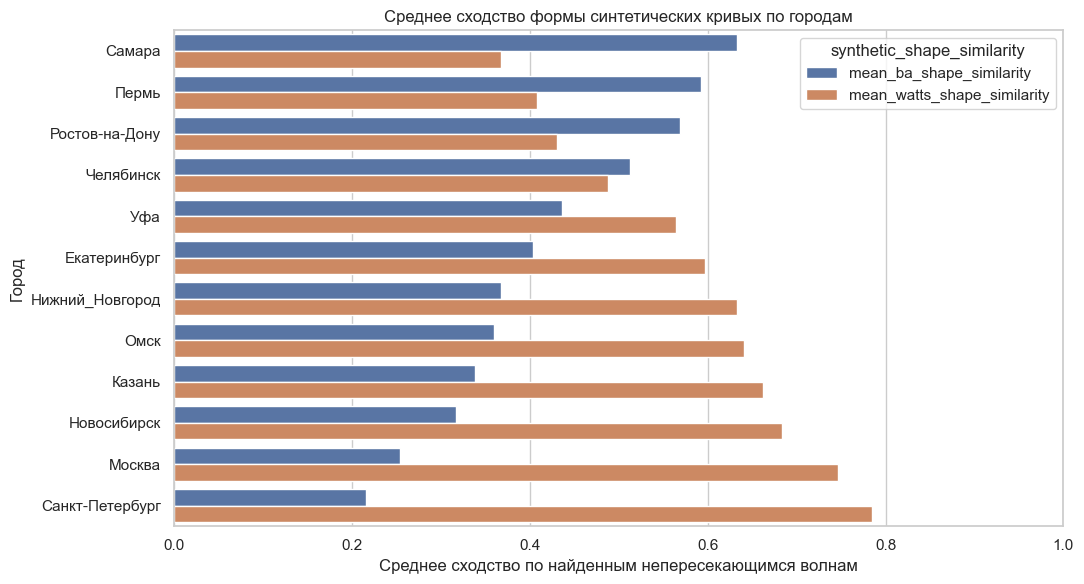

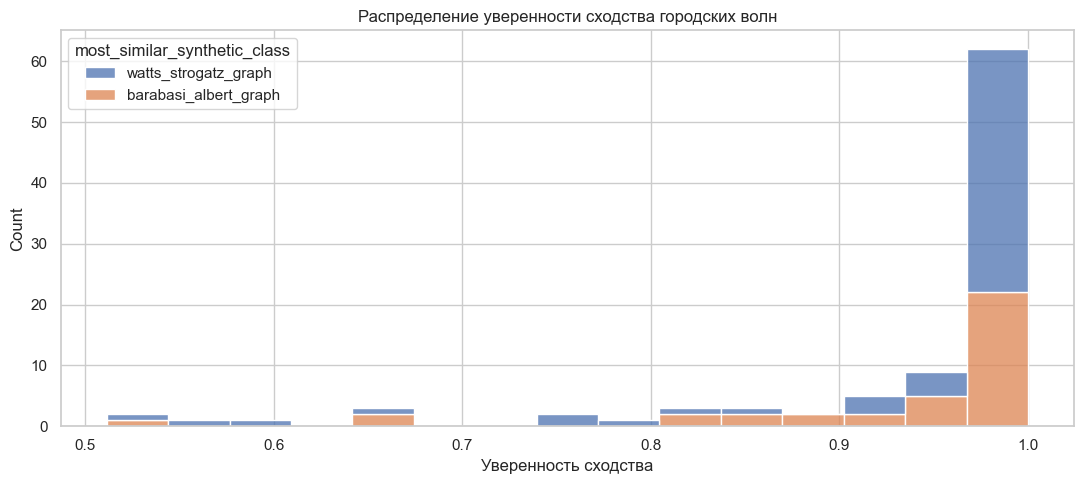

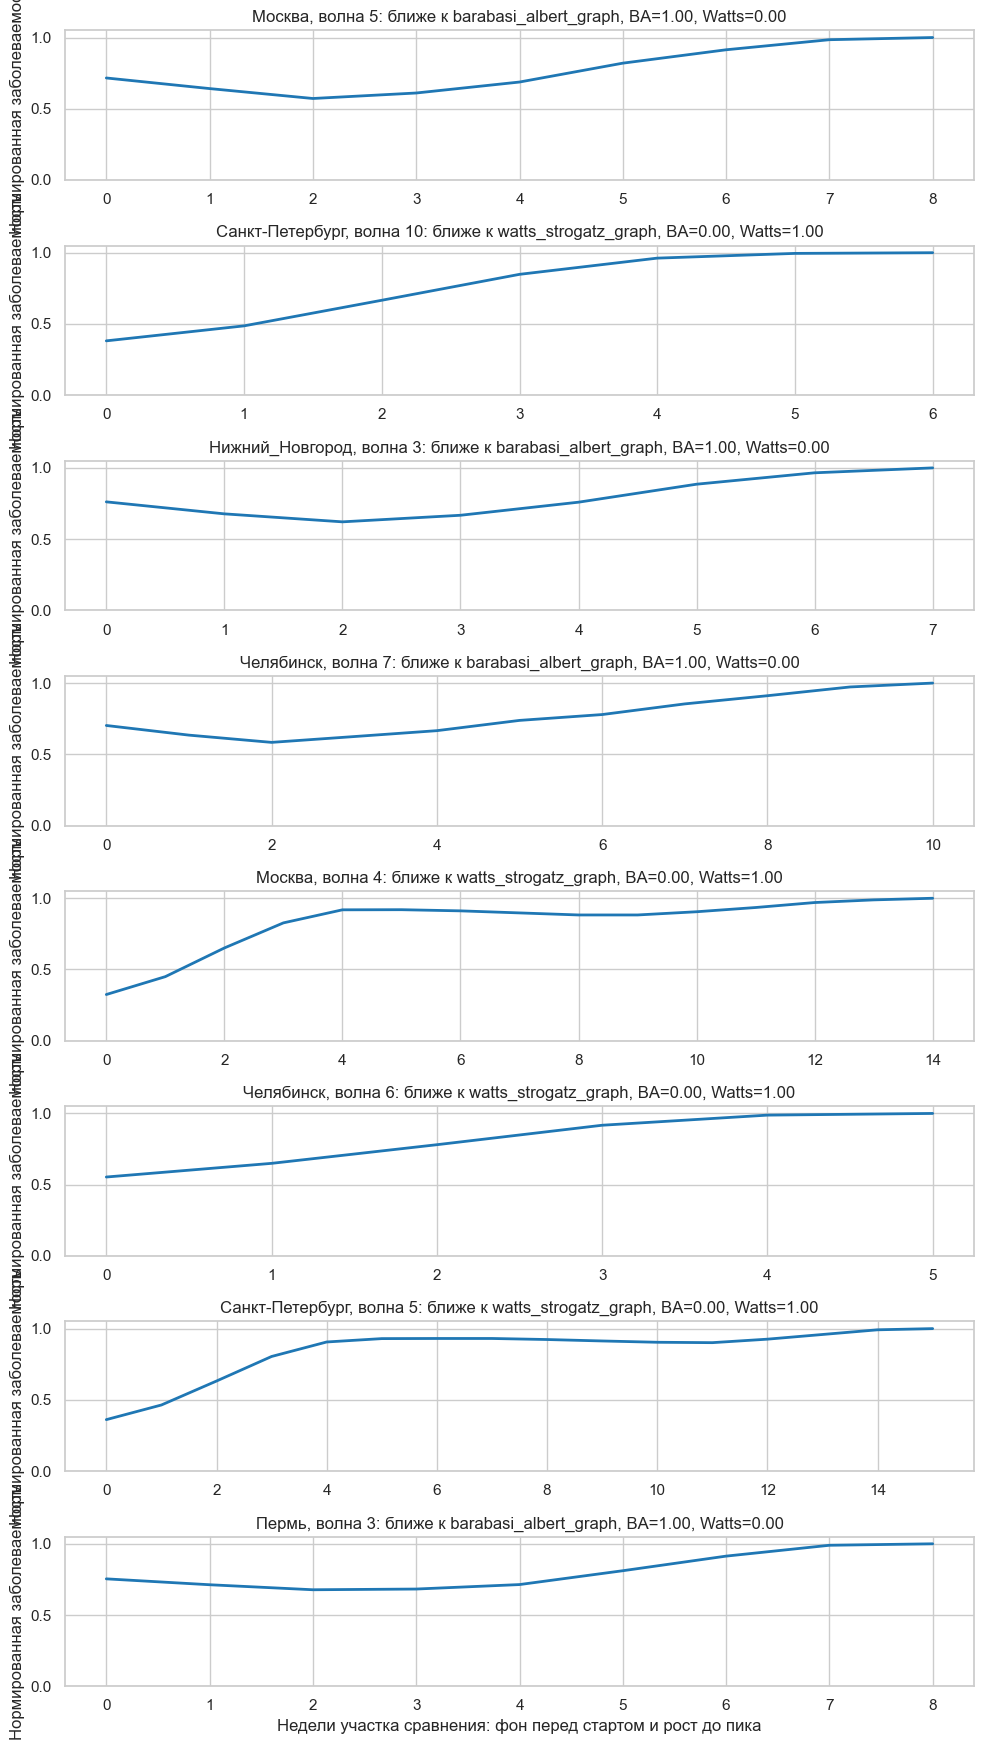

In [16]:
plot_city_similarity_summary(city_summary, city_results)
plot_city_curve_examples(city_results, city_wave_curves)


## 10. Как интерпретировать результаты

- `best_model` — выбранный классификатор синтетических кривых. Он принимается только если на validation у каждого класса recall больше нуля.
- `test_metrics` показывает качество выбранной модели на held-out test. Если хотя бы один класс не распознаётся на test, ноутбук останавливается с ошибкой.
- `city_results` содержит результаты на уровне отдельных городских волн: наиболее похожий синтетический класс и вероятности сходства с BA/Watts-Strogatz.
- `city_summary` агрегирует эти вероятности по городам.
- `city_wave_overlaps` показывает кандидаты волн, удалённые из-за сильного пересечения с более выраженными волнами.
- Сравнение городов и синтетики выполняется по ранней форме волны, а не по абсолютной заболеваемости.
- Городские ряды и синтетические SEIR-кривые относятся к разным доменам данных, поэтому выводы нужно формулировать как exploratory shape matching, а не как доказанную реконструкцию городской сети.
- Если balanced accuracy, macro F1 или per-class recall низкие, нужно расширить и сбалансировать набор синтетических траекторий перед использованием городских результатов в выводах.
